# 🎛️ Interactive Linear Maps — Drive the Transformation Yourself

**Linear Algebra and Analytic Geometry** · TSIW, ESMAD — Polytechnic of Porto
Lesson notebook **08 of 08** · Library: [`linalg_utils`](../packages/python/src/linalg_utils)

> **Assignment alignment** — supplemental/interactive notebook (not part of the graded
> assignments). A hands-on epilogue to notebook 02.

---

Reading about rotations is one thing; *turning the knob* is another. This notebook closes
the series with a small laboratory for the family of maps

$$A(\theta, s_x, s_y, k) \;=\;
R(\theta)\; \begin{pmatrix} s_x & 0 \\ 0 & s_y \end{pmatrix}
\begin{pmatrix} 1 & k \\ 0 & 1 \end{pmatrix}
\qquad \text{(shear, then scale, then rotate)}.$$

Two ways to explore it:

1. a **static parameter sweep** — grids of snapshots that render everywhere, including on
   GitHub;
2. **live sliders** (`ipywidgets`) — run the notebook locally in Jupyter to use them.

## Table of contents

1. [Setup](#setup)
2. [The parameterized map](#map)
3. [Static sweep: one knob at a time](#sweep)
4. [Determinant along the way](#det)
5. [Live sliders (run locally)](#widgets)
6. [Where to go next](#next)

<a id="setup"></a>
## 1 · Setup

In [1]:
# ── Setup: imports, course library, and a consistent figure style ──────────
import sys
from pathlib import Path

# Make the course library importable straight from a repo clone
# (equivalent to `poetry install` inside packages/python).
_SRC = (Path.cwd().parent / "packages" / "python" / "src").resolve()
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette, used in fixed order across the series.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor":   BASE,
    "axes.labelcolor":  INK,
    "axes.titlecolor":  INK,
    "axes.titleweight": "bold",
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.prop_cycle":  plt.cycler(color=PALETTE),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "figure.dpi":       110,
})
np.set_printoptions(precision=4, suppress=True)

import linalg_utils
print("NumPy", np.__version__, "| linalg_utils loaded from", Path(linalg_utils.__file__).parent)

NumPy 2.3.5 | linalg_utils loaded from C:\Users\diogo\work_code\linear-algebra-with-python\packages\python\src\linalg_utils


<a id="map"></a>
## 2 · The parameterized map

A helper composes the three building blocks from notebook 02 and reports the resulting
matrix. We reuse the course library's `unit_circle` / `unit_square` samplers and its
`apply_linear_map`.

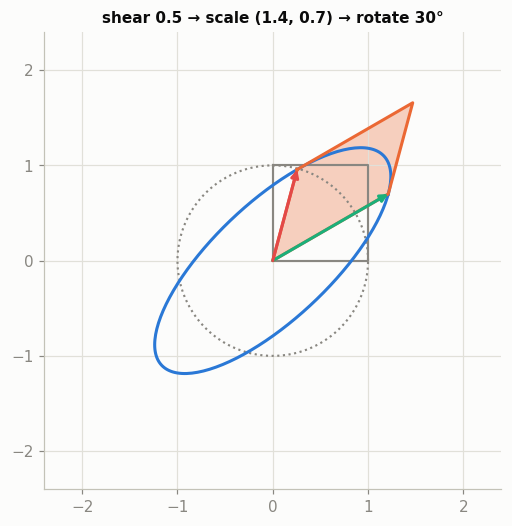

A =
 [[1.2124 0.2562]
 [0.7    0.9562]]


In [2]:
from linalg_utils.geometry2d import unit_circle, unit_square, apply_linear_map

circle = unit_circle()
square = unit_square()


def make_map(theta=0.0, sx=1.0, sy=1.0, k=0.0):
    """Compose shear(k) → scale(sx, sy) → rotate(theta)."""
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    S = np.diag([sx, sy])
    K = np.array([[1.0, k], [0.0, 1.0]])
    return R @ S @ K


def draw_map(ax, A, title=""):
    """Draw the unit circle & square plus their images and the basis images."""
    ax.plot(circle[:, 0], circle[:, 1], color=MUTED, ls=":", lw=1.4)
    ax.plot(square[:, 0], square[:, 1], color=MUTED, lw=1.4)
    mc = apply_linear_map(A, circle)
    ms = apply_linear_map(A, square)
    ax.plot(mc[:, 0], mc[:, 1], color=PALETTE[0], lw=2)
    ax.fill(ms[:, 0], ms[:, 1], color=PALETTE[1], alpha=0.30)
    ax.plot(ms[:, 0], ms[:, 1], color=PALETTE[1], lw=2)
    for col, colr in [(A[:, 0], PALETTE[2]), (A[:, 1], PALETTE[7])]:
        ax.annotate("", xy=tuple(col), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=colr, lw=2,
                                    shrinkA=0, shrinkB=0))
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)


A_demo = make_map(theta=np.pi / 6, sx=1.4, sy=0.7, k=0.5)
fig, ax = plt.subplots(figsize=(5.6, 5.4))
draw_map(ax, A_demo, "shear 0.5 → scale (1.4, 0.7) → rotate 30°")
plt.show()
print("A =\n", A_demo.round(4))

<a id="sweep"></a>
## 3 · Static sweep: one knob at a time

Each row varies a single parameter while the others stay at their neutral value — a
flip-book of how each knob deforms the plane. Green/red arrows are the images of
$\mathbf{e}_1$/$\mathbf{e}_2$ (the matrix columns, as always).

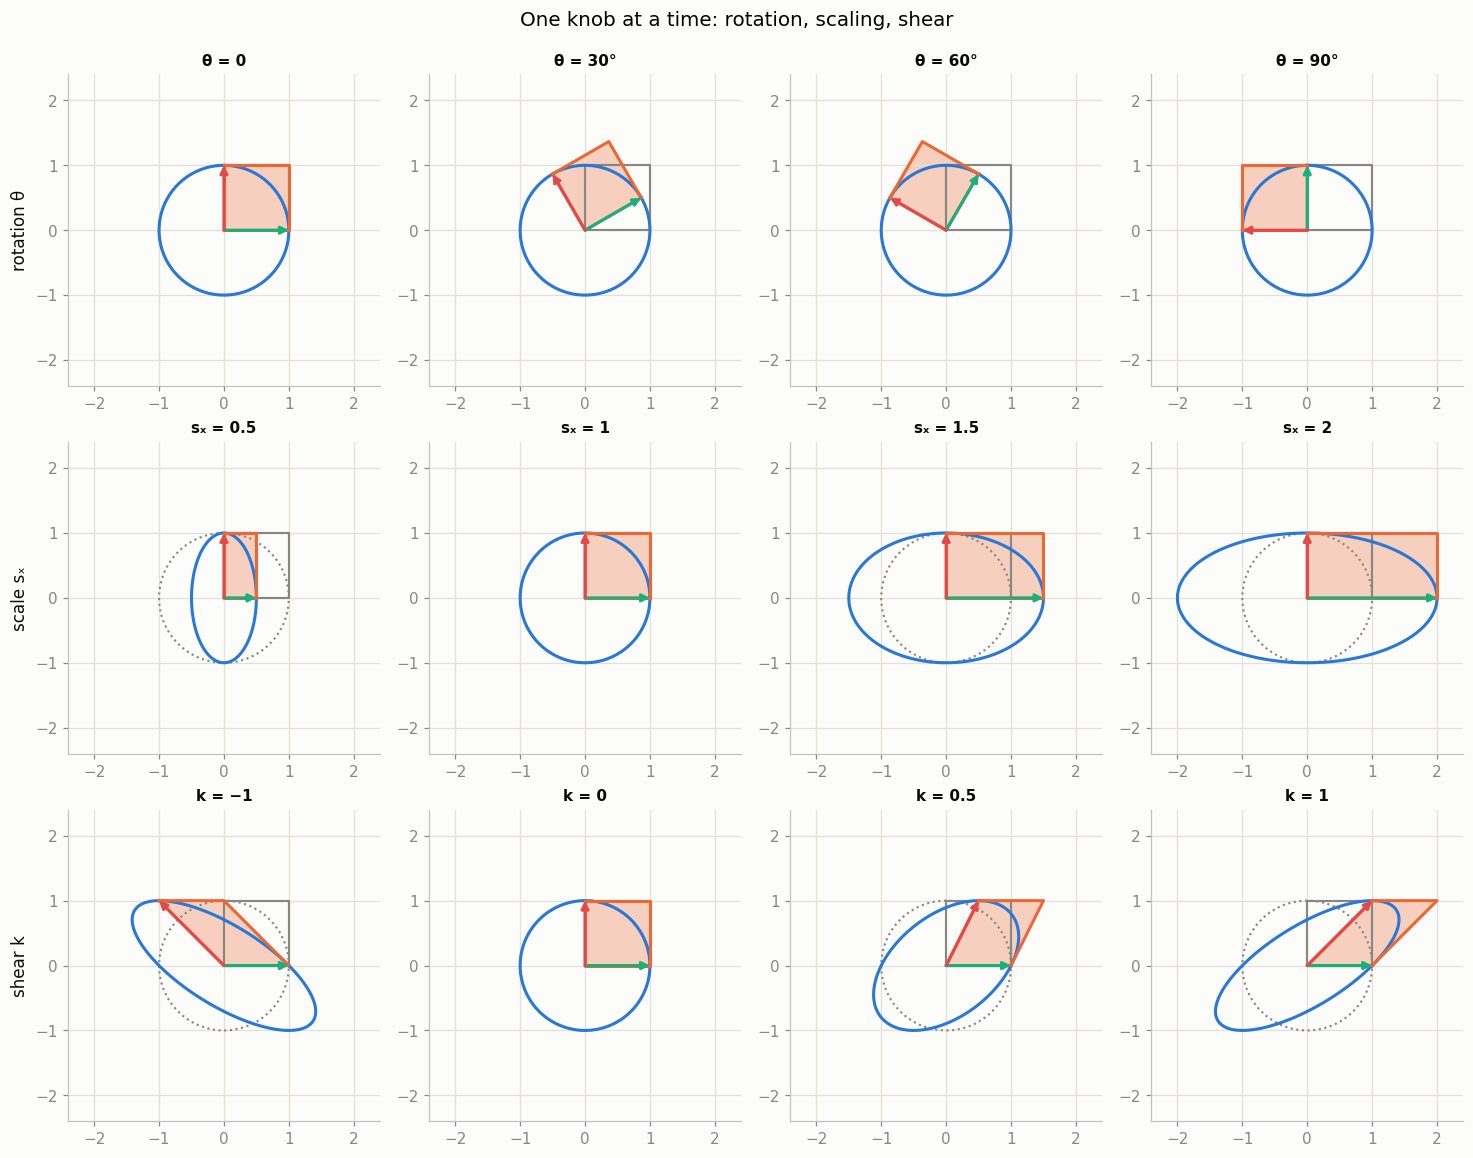

In [3]:
sweeps = [
    ("rotation θ", [("θ = 0", {}), ("θ = 30°", {"theta": np.pi/6}),
                    ("θ = 60°", {"theta": np.pi/3}), ("θ = 90°", {"theta": np.pi/2})]),
    ("scale sₓ",   [("sₓ = 0.5", {"sx": 0.5}), ("sₓ = 1", {}),
                    ("sₓ = 1.5", {"sx": 1.5}), ("sₓ = 2", {"sx": 2.0})]),
    ("shear k",    [("k = −1", {"k": -1.0}), ("k = 0", {}),
                    ("k = 0.5", {"k": 0.5}), ("k = 1", {"k": 1.0})]),
]

fig, axes = plt.subplots(3, 4, figsize=(13.5, 10.5))
for row, (name, cases) in zip(axes, sweeps):
    for ax, (label, kwargs) in zip(row, cases):
        draw_map(ax, make_map(**kwargs), label)
    row[0].set_ylabel(name, fontsize=11, color=INK)
fig.suptitle("One knob at a time: rotation, scaling, shear", y=0.995, fontsize=13)
plt.tight_layout()
plt.show()

<a id="det"></a>
## 4 · Determinant along the way

The determinant of the composition factors neatly:
$\det A = \underbrace{1}_{\text{rotation}} \cdot \underbrace{s_x s_y}_{\text{scale}} \cdot \underbrace{1}_{\text{shear}} = s_x s_y$.
Rotation and shear leave area untouched — only the scaling knob changes it. We confirm by
sweeping $s_x$ continuously and measuring $\det$ numerically.

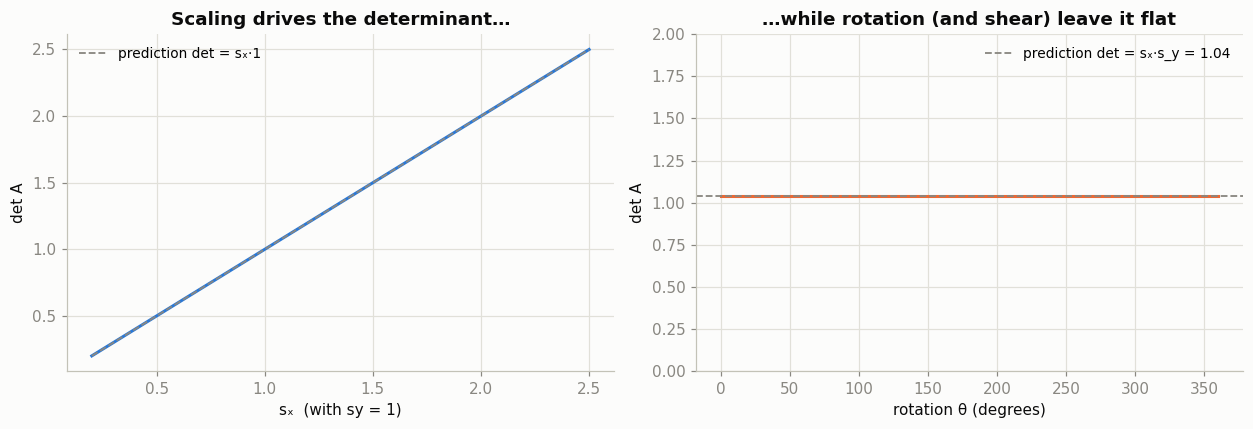

In [4]:
sx_grid = np.linspace(0.2, 2.5, 60)
dets_scale = [np.linalg.det(make_map(sx=s)) for s in sx_grid]
theta_grid = np.linspace(0, 2 * np.pi, 60)
dets_theta = [np.linalg.det(make_map(theta=t, sx=1.3, sy=0.8, k=0.7)) for t in theta_grid]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].plot(sx_grid, dets_scale, color=PALETTE[0], lw=2)
axes[0].plot(sx_grid, sx_grid, color=MUTED, ls="--", lw=1.2, label="prediction det = sₓ·1")
axes[0].set_xlabel("sₓ  (with sy = 1)")
axes[0].set_ylabel("det A")
axes[0].set_title("Scaling drives the determinant…")
axes[0].legend(fontsize=9)

axes[1].plot(np.degrees(theta_grid), dets_theta, color=PALETTE[1], lw=2)
axes[1].axhline(1.3 * 0.8, color=MUTED, ls="--", lw=1.2,
                label="prediction det = sₓ·s_y = 1.04")
axes[1].set_xlabel("rotation θ (degrees)")
axes[1].set_ylabel("det A")
axes[1].set_ylim(0, 2)
axes[1].set_title("…while rotation (and shear) leave it flat")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

<a id="widgets"></a>
## 5 · Live sliders (run locally)

Run this cell in Jupyter (`pip install ipywidgets`, bundled with the course environment) and
drag the four sliders — the figure re-renders on every change. *GitHub renders widgets as a
static placeholder; the cell is fully functional in a live kernel.*

In [5]:
import ipywidgets as widgets
from IPython.display import display


def explore(theta=0.0, sx=1.0, sy=1.0, k=0.0):
    A = make_map(theta, sx, sy, k)
    fig, ax = plt.subplots(figsize=(5.4, 5.2))
    draw_map(ax, A,
             f"θ = {np.degrees(theta):.0f}°, s = ({sx:.2f}, {sy:.2f}), k = {k:.2f}"
             f"   →   det = {np.linalg.det(A):+.2f}")
    plt.show()


widgets.interact(
    explore,
    theta=widgets.FloatSlider(value=0.5, min=-np.pi, max=np.pi, step=0.05,
                              description="rotation θ"),
    sx=widgets.FloatSlider(value=1.3, min=0.2, max=2.5, step=0.05, description="scale sₓ"),
    sy=widgets.FloatSlider(value=0.8, min=0.2, max=2.5, step=0.05, description="scale s_y"),
    k=widgets.FloatSlider(value=0.0, min=-1.5, max=1.5, step=0.05, description="shear k"),
);

interactive(children=(FloatSlider(value=0.5, description='rotation θ', max=3.141592653589793, min=-3.141592653…

<a id="next"></a>
## 6 · Where to go next

You have now seen the full arc of the series:

| # | notebook | one-line summary |
|---|---|---|
| 01 | [Vectors & dot products](01_vectors_and_dot_products.ipynb) | arrows, angles, shadows |
| 02 | [Matrices as linear maps](02_matrices_and_linear_maps.ipynb) | columns = images of the basis |
| 03 | [Solving linear systems](03_solving_linear_systems.ipynb) | elimination, SPD/SPI/SI, conditioning |
| 04 | [Least squares](04_least_squares_and_projections.ipynb) | best answer when none is exact |
| 05 | [QR & SVD](05_qr_and_svd.ipynb) | orthonormal bases; rotate·stretch·rotate |
| 06 | [Eigenvalues](06_eigenvalues_and_diagonalization.ipynb) | invariant directions, $A^k$ made cheap |
| 07 | [PCA](07_pca_mini_project.ipynb) | the data's own axes |
| 08 | this one | drive the maps yourself |

**Suggested experiments** with the sliders above:

- Set $s_x = s_y$ and vary $\theta$: which shapes stay circles? Why?
- Find parameter values that make $\det A = 0$. What happens to the square?
- With $k \neq 0$, can a rotation ever undo a shear? (Compare notebook 02 §8.)

From here, the [assignments](../assignments/) apply this toolkit — and the
[capstone](../capstone/starter.ipynb) puts it all together.